In [38]:
# !python -m spacy download es_core_news_sm

In [39]:
documents = []
etiquetas = []
with open("paths.txt", "r", encoding="utf-8") as f:
    paths = f.readlines()
    for path in paths:
        path = path.strip()
        etiquetas.append(path[path.rindex("\\")+1:-4].lower())
        ff = open(path, "r", encoding="utf-8")
        documents.append("".join(ff.readlines()).replace("\n", " ").strip().lower())

documents
etiquetas

['el leve pedro',
 'el pansori y su similitud con el flamenco',
 'estudios de folclor, cultura popular y patrimonio cultural inmaterial (1909-2003)',
 'guía organizaciones sindicales',
 'la actividad física es tu medicina',
 'qué es la economía y de qué se ocupa',
 'restauración, el arte detrás del arte',
 'textiles de polietileno, un paso de la moda rápida hacia la moda sustentable',
 'chile artesanía',
 'el arte y la ciencia de no hacer nada, el piloto automático del cerebro',
 'el barco a vapor',
 'humberstone y santa laura',
 'las mujeres y la radio, en plena sintonía',
 'medicina y cirugía antiguas',
 'psicología fisiológica',
 'tus mensajes dicen mucho de ti',
 'discurso de recepción del premio nobel de literatura',
 'la tensión puerto-balneario en valparaíso',
 'módulo 1, introducción a la gestión de las artes escénicas',
 'qué es la psicología',
 'ruta de la seguridad social. guía informativa de derechos y beneficios',
 'un oasis de dicha',
 'de los palos de conteo a la escritu

In [40]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text

for style in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid", "default"]:
    if style in plt.style.available or style == "default":
        plt.style.use(style)
        break

vectorizer_raw = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    min_df=1,
)

X_raw = vectorizer_raw.fit_transform(documents)
vocabulario_raw = vectorizer_raw.get_feature_names_out()
A_raw = X_raw.toarray().T

print("Forma de X_raw (documentos x terminos):", X_raw.shape)
print("Forma de A_raw (terminos x documentos):", A_raw.shape)
print("Primeros terminos del vocabulario:", vocabulario_raw[:30])

Forma de X_raw (documentos x terminos): (57, 9810)
Forma de A_raw (terminos x documentos): (9810, 57)
Primeros terminos del vocabulario: ['abajo' 'abandona' 'abandonado' 'abandonando' 'abandonar' 'abandonos'
 'abandonó' 'abanico' 'abarca' 'abarcar' 'abarcó' 'abarrotamos' 'abedules'
 'abetos' 'abierta' 'abierto' 'abiertos' 'abismos' 'abocan' 'abogacía'
 'abogado' 'abordadas' 'abordaje' 'abordar' 'abordó' 'abrazados' 'abre'
 'abriendo' 'abrieron' 'abrigan']


,estadistica,corpus_sin_limpieza
0,numero_documentos,57
1,numero_terminos,9810
2,forma_X_documentos_x_terminos,57 x 9810
3,forma_A_terminos_x_documentos,9810 x 57
4,entradas_no_cero,22616
5,densidad,0.0404
6,sparsity,0.9596


,estadistica,corpus_sin_limpieza
0,min,216.00
1,mediana,719.00
2,media,682.11
3,max,1004.00


,estadistica,corpus_sin_limpieza
0,min,147.00
1,mediana,414.00
2,media,396.77
3,max,597.00


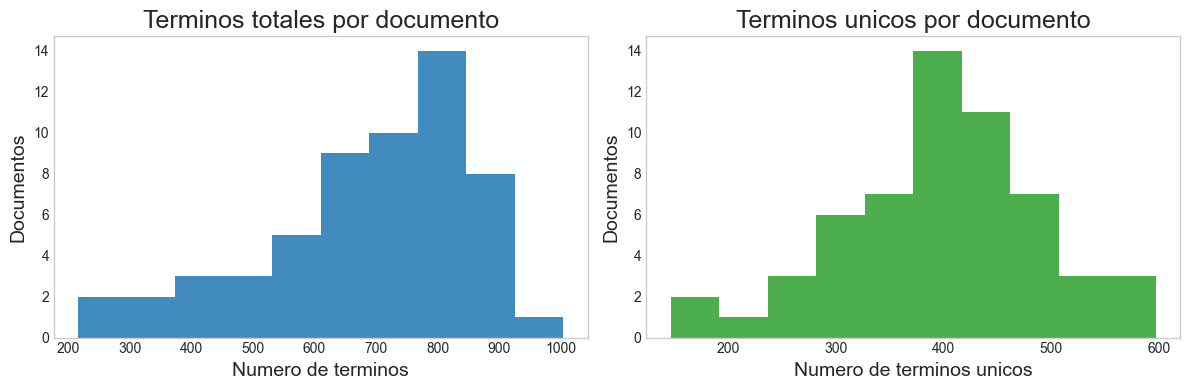

In [41]:
import numpy as np

def tabla_resumen_distribucion(nombre, valores):
    return pd.DataFrame(
        [
            ["min", int(valores.min())],
            ["mediana", int(np.median(valores))],
            ["media", round(float(valores.mean()), 2)],
            ["max", int(valores.max())],
        ],
        columns=["estadistica", nombre],
    )


def resumen_vectorizacion(nombre, X, A, vocabulario):
    conteos_por_doc = np.asarray(X.sum(axis=1)).ravel()
    terminos_unicos_por_doc = np.asarray((X > 0).sum(axis=1)).ravel()
    total_celdas = X.shape[0] * X.shape[1]
    densidad = X.nnz / total_celdas

    tabla_corpus = pd.DataFrame(
        [
            ["numero_documentos", X.shape[0]],
            ["numero_terminos", X.shape[1]],
            ["forma_X_documentos_x_terminos", f"{X.shape[0]} x {X.shape[1]}"],
            ["forma_A_terminos_x_documentos", f"{A.shape[0]} x {A.shape[1]}"],
            ["entradas_no_cero", X.nnz],
            ["densidad", round(float(densidad), 4)],
            ["sparsity", round(float(1 - densidad), 4)],
        ],
        columns=["estadistica", nombre],
    )
    tabla_terminos_por_doc = tabla_resumen_distribucion(nombre, conteos_por_doc)
    tabla_terminos_unicos_por_doc = tabla_resumen_distribucion(nombre, terminos_unicos_por_doc)

    return (
        tabla_corpus,
        tabla_terminos_por_doc,
        tabla_terminos_unicos_por_doc,
        conteos_por_doc,
        terminos_unicos_por_doc,
    )

(
    tabla_corpus_raw,
    tabla_terminos_por_doc_raw,
    tabla_terminos_unicos_por_doc_raw,
    conteos_doc_raw,
    terminos_unicos_doc_raw,
) = resumen_vectorizacion(
    "corpus_sin_limpieza",
    X_raw,
    A_raw,
    vocabulario_raw,
)

display(tabla_corpus_raw)
display(tabla_terminos_por_doc_raw)
display(tabla_terminos_unicos_por_doc_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(conteos_doc_raw, bins=10, color="tab:blue", alpha=0.85)
axes[0].set_title("Terminos totales por documento", fontsize=18)
axes[0].set_xlabel("Numero de terminos", fontsize=14)
axes[0].set_ylabel("Documentos", fontsize=14)
axes[0].grid(False)

axes[1].hist(terminos_unicos_doc_raw, bins=10, color="tab:green", alpha=0.85)
axes[1].set_title("Terminos unicos por documento", fontsize=18)
axes[1].set_xlabel("Numero de terminos unicos", fontsize=14)
axes[1].set_ylabel("Documentos", fontsize=14)
axes[1].grid(False)

plt.tight_layout()
plt.show()

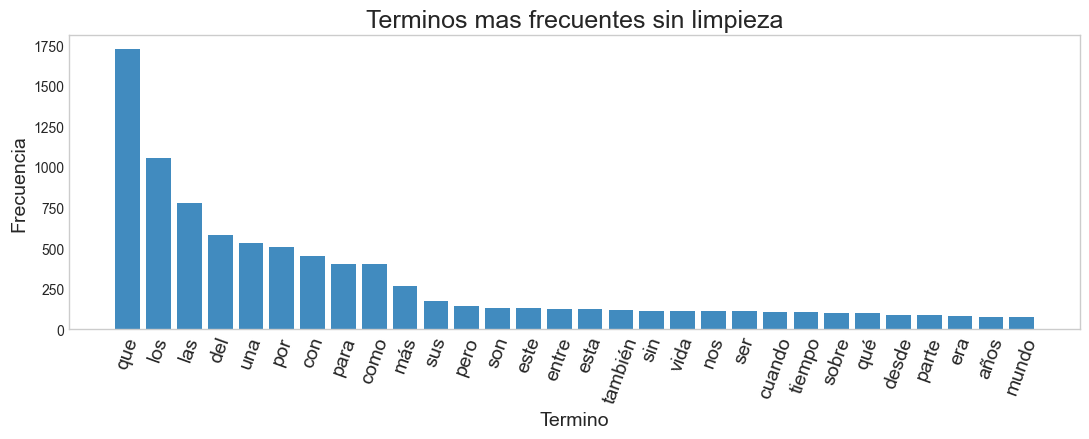

Top 30 terminos mas frecuentes sin limpieza:


array(['que', 'los', 'las', 'del', 'una', 'por', 'con', 'para', 'como',
       'más', 'sus', 'pero', 'son', 'este', 'entre', 'esta', 'también',
       'sin', 'vida', 'nos', 'ser', 'cuando', 'tiempo', 'sobre', 'qué',
       'desde', 'parte', 'era', 'años', 'mundo'], dtype=object)

In [42]:
frecuencias_raw = np.asarray(X_raw.sum(axis=0)).ravel()
indices_frecuentes_raw = np.argsort(frecuencias_raw)[::-1][:30]
terminos_frecuentes_raw = vocabulario_raw[indices_frecuentes_raw]
conteos_frecuentes_raw = frecuencias_raw[indices_frecuentes_raw]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(terminos_frecuentes_raw, conteos_frecuentes_raw, color="tab:blue", alpha=0.85)
ax.set_title("Terminos mas frecuentes sin limpieza", fontsize=18)
ax.set_xlabel("Termino", fontsize=14)
ax.set_ylabel("Frecuencia", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=14)
plt.tight_layout()
plt.show()
# Print top 30 terms and their counts
print("Top 30 terminos mas frecuentes sin limpieza:")
terminos_frecuentes_raw

In [43]:
import spacy

try:
    nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
except OSError as exc:
    raise OSError(
        "No encontre el modelo es_core_news_sm. Ejecuta la celda de instalacion: "
        "!python -m spacy download es_core_news_sm"
    ) from exc

with open("./stopword.txt", encoding="utf-8") as f:
    stop_words = [l.strip() for l in f.readlines()]

stop_words_raw = sorted(set(stop_words))


def lematizar_lista(palabras):
    lemas = set()
    for palabra in palabras:
        doc = nlp(palabra)
        for token in doc:
            lema = token.lemma_.lower().strip()
            if lema:
                lemas.add(lema)
    return lemas


# Filtramos dos veces: primero en la forma original del token y luego en su lema.
# Esto evita que ruido de LaTeX como mathbb, times, hat o ldots sobreviva por cambios del lematizador.
stop_words_lem = lematizar_lista(stop_words_raw)
stop_words_total = sorted(set(stop_words_raw) | stop_words_lem)


def lematizar_texto(texto):
    doc = nlp(texto)
    lemas = []
    for token in doc:
        texto_token = token.text.lower().strip()
        lema = token.lemma_.lower().strip()
        if not texto_token or not lema or token.is_space:
            continue
        if len(texto_token) < 3 or len(lema) < 3:
            continue
        if texto_token in stop_words_total or lema in stop_words_total:
            continue
        lemas.append(lema)
    return " ".join(lemas)

documentos_lem = [lematizar_texto(texto) for texto in documents]


print("Ejemplo original:")
print(documents[0][:300])
print("\nEjemplo lematizado y filtrado:")
print(documentos_lem[0][:300])
print("\nStopwords finales:", stop_words_total[:40])

Ejemplo original:
el leve pedro  durante dos meses se asomó a la muerte. el médico refunfuñaba que la enfermedad de pedro era nueva, que no había modo de tratarse y que él no sabía qué hacer… por suerte el enfermo, solito, se fue curando. no había perdido su buen humor, su oronda calma provinciana. demasiado flaco y 

Ejemplo lematizado y filtrado:
leve pedro mes asomar muerte médico refunfuñar enfermedad pedro tratar él suerte enfermo solito curar perder humor orondo calma provincián demasiado flaco levantar él semana convalecencia peso oir mujer cuerpo ausente envoltura desprender él dejándome alma desnudir languidez responder mujer recobrar

Stopwords finales: ["'", 'a', 'acerca', 'actualmente', 'adelante', 'además', 'adonde', 'afirmar', 'afirmó', 'agregar', 'agregó', 'ahora', 'ahí', 'al', 'algo', 'alguna', 'algunas', 'alguno', 'algunos', 'algún', 'allende', 'allendir', 'alrededor', 'ambos', 'ampleamos', 'amplear', 'amén', 'ante', 'anterior', 'antes', 'apenas', 'aproximadamente', 'a

In [44]:
vectorizer_final = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[^\W\d_]{3,}\b",
    stop_words=stop_words_total,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
)

X_final = vectorizer_final.fit_transform(documentos_lem)
vocabulario_final = vectorizer_final.get_feature_names_out()
A_final = X_final.toarray().T

vectorizer_final_counts = CountVectorizer(vocabulary=vocabulario_final)
X_final_counts = vectorizer_final_counts.transform(documentos_lem)
frecuencias_final = np.asarray(X_final_counts.sum(axis=0)).ravel()

print("Forma de X_final (documentos x terminos):", X_final.shape)
print("Forma de A_final (terminos x documentos):", A_final.shape)
print("Primeros terminos del vocabulario final:", vocabulario_final[:30])
print("Unigramas:", sum(len(t.split()) == 1 for t in vocabulario_final))
print("Bigramas:", sum(len(t.split()) == 2 for t in vocabulario_final))

Forma de X_final (documentos x terminos): (57, 2756)
Forma de A_final (terminos x documentos): (2756, 57)
Primeros terminos del vocabulario final: ['abajo' 'abandonar' 'abarcar' 'abierto' 'abordar' 'abrigo' 'abril'
 'abrir' 'abrir escuela' 'abrir paso' 'absoluto' 'absorber' 'abstracción'
 'abstracto' 'abuelo' 'acabado' 'acabar' 'academia' 'académico'
 'acalambrar' 'acariciar' 'acaso' 'acceder' 'acceso' 'accidente'
 'accionar' 'acción' 'aceite' 'acelerado' 'aceptar']
Unigramas: 2476
Bigramas: 280


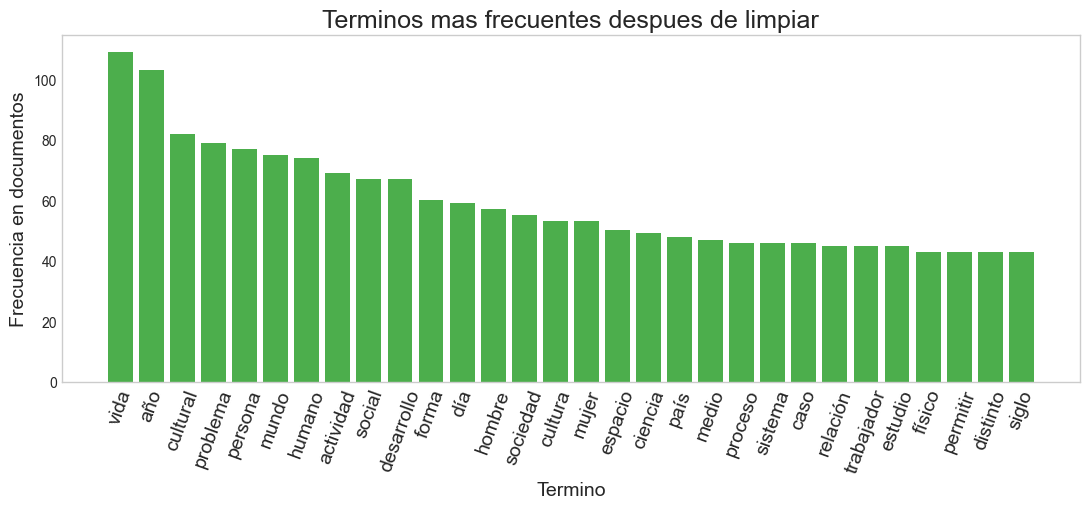

Top 30 terminos mas frecuentes despues de limpiar:


array(['vida', 'año', 'cultural', 'problema', 'persona', 'mundo',
       'humano', 'actividad', 'social', 'desarrollo', 'forma', 'día',
       'hombre', 'sociedad', 'cultura', 'mujer', 'espacio', 'ciencia',
       'país', 'medio', 'proceso', 'sistema', 'caso', 'relación',
       'trabajador', 'estudio', 'físico', 'permitir', 'distinto', 'siglo'],
      dtype=object)

In [45]:
indices_frecuentes_final = np.argsort(frecuencias_final)[::-1][:30]
terminos_frecuentes_final = vocabulario_final[indices_frecuentes_final]
conteos_frecuentes_final = frecuencias_final[indices_frecuentes_final]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.bar(terminos_frecuentes_final, conteos_frecuentes_final, color="tab:green", alpha=0.85)
ax.set_title("Terminos mas frecuentes despues de limpiar", fontsize=18)
ax.set_xlabel("Termino", fontsize=14)
ax.set_ylabel("Frecuencia en documentos", fontsize=14)
ax.grid(False)
ax.tick_params(axis="x", rotation=70, labelsize=14)
plt.tight_layout()
plt.show()

# Print top 30 terms and their counts
print("Top 30 terminos mas frecuentes despues de limpiar:")
terminos_frecuentes_final

,estadistica,corpus_sin_limpieza,despues_preprocesamiento
0,numero_documentos,57,57
1,numero_terminos,9810,2756
2,forma_X_documentos_x_terminos,57 x 9810,57 x 2756
3,forma_A_terminos_x_documentos,9810 x 57,2756 x 57
4,entradas_no_cero,22616,11138
5,densidad,0.0404,0.0709
6,sparsity,0.9596,0.9291


,estadistica,corpus_sin_limpieza,despues_preprocesamiento
0,min,216.00,83.00
1,mediana,719.00,319.00
2,media,682.11,307.19
3,max,1004.00,480.00


,estadistica,corpus_sin_limpieza,despues_preprocesamiento
0,min,147.00,60.0
1,mediana,414.00,199.0
2,media,396.77,195.4
3,max,597.00,308.0


,estadistica,antes,despues,cambio_%
0,numero_terminos,9810.0000,2756.0000,-71.91
1,entradas_no_cero,22616.0000,11138.0000,-50.75
2,densidad,0.0404,0.0709,75.50
3,sparsity,0.9596,0.9291,-3.18
4,media_terminos_por_doc,682.1100,307.1900,-54.96
5,media_terminos_unicos_por_doc,396.7700,195.4000,-50.75


,estadistica,despues_preprocesamiento
0,unigramas_vocabulario_final,2476
1,bigramas_vocabulario_final,280
2,forma_X_final_tfidf_documentos_x_terminos,57 x 2756
3,forma_A_final_tfidf_terminos_x_documentos,2756 x 57


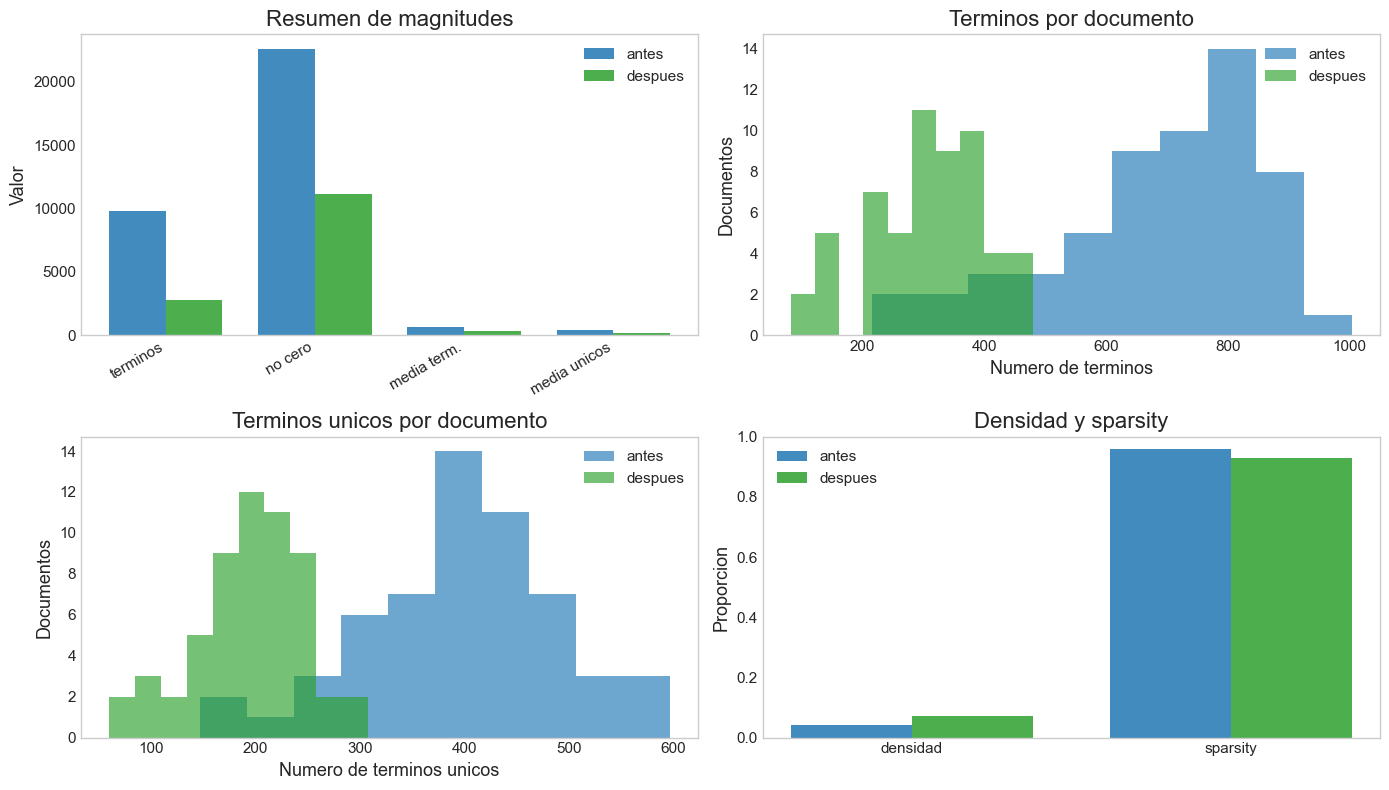

In [46]:
(
    tabla_corpus_final,
    tabla_terminos_por_doc_final,
    tabla_terminos_unicos_por_doc_final,
    conteos_doc_final,
    terminos_unicos_doc_final,
) = resumen_vectorizacion(
    "despues_preprocesamiento",
    X_final_counts,
    A_final,
    vocabulario_final,
)

tabla_corpus_comparacion = tabla_corpus_raw.merge(tabla_corpus_final, on="estadistica")
tabla_terminos_por_doc = tabla_terminos_por_doc_raw.merge(tabla_terminos_por_doc_final, on="estadistica")
tabla_terminos_unicos_por_doc = tabla_terminos_unicos_por_doc_raw.merge(tabla_terminos_unicos_por_doc_final, on="estadistica")


def valor_numerico(tabla, estadistica, columna):
    return float(tabla.loc[tabla["estadistica"] == estadistica, columna].iloc[0])


def fila_cambio(tabla, estadistica, nombre):
    antes = valor_numerico(tabla, estadistica, "corpus_sin_limpieza")
    despues = valor_numerico(tabla, estadistica, "despues_preprocesamiento")
    cambio_pct = 100 * (despues - antes) / antes if antes != 0 else np.nan
    return [nombre, antes, despues, round(cambio_pct, 2)]


filas_cambio = [
    fila_cambio(tabla_corpus_comparacion, "numero_terminos", "numero_terminos"),
    fila_cambio(tabla_corpus_comparacion, "entradas_no_cero", "entradas_no_cero"),
    fila_cambio(tabla_corpus_comparacion, "densidad", "densidad"),
    fila_cambio(tabla_corpus_comparacion, "sparsity", "sparsity"),
    fila_cambio(tabla_terminos_por_doc, "media", "media_terminos_por_doc"),
    fila_cambio(tabla_terminos_unicos_por_doc, "media", "media_terminos_unicos_por_doc"),
]

tabla_cambio = pd.DataFrame(
    filas_cambio,
    columns=["estadistica", "antes", "despues", "cambio_%"],
)

tabla_final_extra = pd.DataFrame(
    [
        ["unigramas_vocabulario_final", sum(len(t.split()) == 1 for t in vocabulario_final)],
        ["bigramas_vocabulario_final", sum(len(t.split()) == 2 for t in vocabulario_final)],
        ["forma_X_final_tfidf_documentos_x_terminos", f"{X_final.shape[0]} x {X_final.shape[1]}"],
        ["forma_A_final_tfidf_terminos_x_documentos", f"{A_final.shape[0]} x {A_final.shape[1]}"],
    ],
    columns=["estadistica", "despues_preprocesamiento"],
)

display(tabla_corpus_comparacion)
display(tabla_terminos_por_doc)
display(tabla_terminos_unicos_por_doc)
display(tabla_cambio)
display(tabla_final_extra)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
colores = ["tab:blue", "tab:green"]

metricas_barras = [
    (tabla_corpus_comparacion, "numero_terminos", "terminos"),
    (tabla_corpus_comparacion, "entradas_no_cero", "no cero"),
    (tabla_terminos_por_doc, "media", "media term."),
    (tabla_terminos_unicos_por_doc, "media", "media unicos"),
]
valores_antes = [valor_numerico(tabla, estadistica, "corpus_sin_limpieza") for tabla, estadistica, _ in metricas_barras]
valores_despues = [valor_numerico(tabla, estadistica, "despues_preprocesamiento") for tabla, estadistica, _ in metricas_barras]
etiquetas_barras = [etiqueta for _, _, etiqueta in metricas_barras]
x = np.arange(len(metricas_barras))
ancho = 0.38
axes[0].bar(x - ancho / 2, valores_antes, width=ancho, label="antes", color=colores[0], alpha=0.85)
axes[0].bar(x + ancho / 2, valores_despues, width=ancho, label="despues", color=colores[1], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(etiquetas_barras, rotation=30, ha="right", fontsize=12)
axes[0].set_title("Resumen de magnitudes", fontsize=16)
axes[0].set_ylabel("Valor", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(False)

axes[1].hist(conteos_doc_raw, bins=10, alpha=0.65, label="antes", color=colores[0])
axes[1].hist(conteos_doc_final, bins=10, alpha=0.65, label="despues", color=colores[1])
axes[1].set_title("Terminos por documento", fontsize=16)
axes[1].set_xlabel("Numero de terminos", fontsize=13)
axes[1].set_ylabel("Documentos", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(False)

axes[2].hist(terminos_unicos_doc_raw, bins=10, alpha=0.65, label="antes", color=colores[0])
axes[2].hist(terminos_unicos_doc_final, bins=10, alpha=0.65, label="despues", color=colores[1])
axes[2].set_title("Terminos unicos por documento", fontsize=16)
axes[2].set_xlabel("Numero de terminos unicos", fontsize=13)
axes[2].set_ylabel("Documentos", fontsize=13)
axes[2].legend(fontsize=11)
axes[2].grid(False)

metricas_densidad = ["densidad", "sparsity"]
valores_antes = [valor_numerico(tabla_corpus_comparacion, m, "corpus_sin_limpieza") for m in metricas_densidad]
valores_despues = [valor_numerico(tabla_corpus_comparacion, m, "despues_preprocesamiento") for m in metricas_densidad]
x = np.arange(len(metricas_densidad))
axes[3].bar(x - ancho / 2, valores_antes, width=ancho, label="antes", color=colores[0], alpha=0.85)
axes[3].bar(x + ancho / 2, valores_despues, width=ancho, label="despues", color=colores[1], alpha=0.85)
axes[3].set_xticks(x)
axes[3].set_xticklabels(metricas_densidad, fontsize=12)
axes[3].set_ylim(0, 1)
axes[3].set_title("Densidad y sparsity", fontsize=16)
axes[3].set_ylabel("Proporcion", fontsize=13)
axes[3].legend(fontsize=11)
axes[3].grid(False)

for ax in axes:
    ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()

Primeros valores singulares con stopwords + Lematizacion + TF-IDF + bigramas:
[2.028 1.32  1.253 1.233 1.203 1.166 1.139 1.123 1.115 1.095]


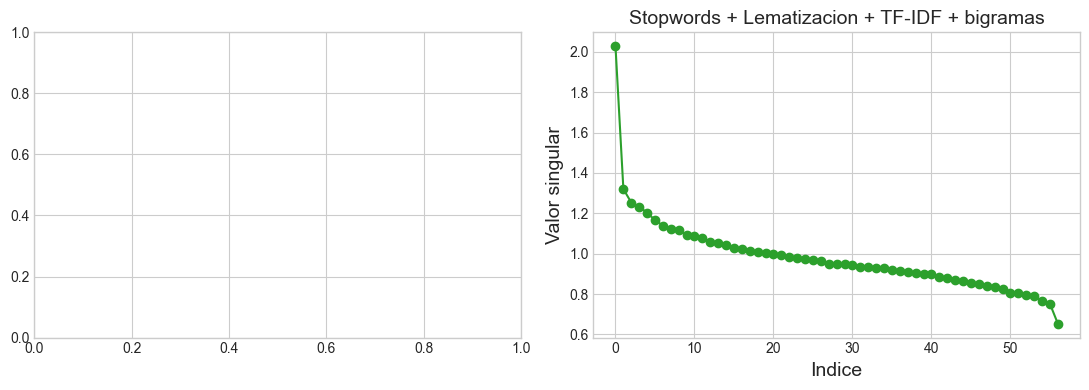

In [47]:
U_final, s_final, VT_final = np.linalg.svd(A_final, full_matrices=False)

print("Primeros valores singulares con stopwords + Lematizacion + TF-IDF + bigramas:")
print(np.round(s_final[:10], 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[1].plot(s_final, marker="o", color="tab:green")
axes[1].set_title("Stopwords + Lematizacion + TF-IDF + bigramas", fontsize=14)
axes[1].set_xlabel("Indice", fontsize=14)
axes[1].set_ylabel("Valor singular", fontsize=14)

plt.tight_layout()
plt.show()

In [48]:
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm


def coordenadas_documentos(s, VT, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return np.diag(s[indices]) @ VT[indices, :]


def coordenadas_terminos(U, s, componentes=(1, 2)):
    indices = [componente - 1 for componente in componentes]
    return U[:, indices] @ np.diag(s[indices])


def etiqueta_corta_documento(etiqueta):
    return Path(etiqueta).stem


def grupo_documento(etiqueta):
    partes = etiqueta.split("/")
    if len(partes) >= 3 and partes[0] == "semana" and partes[1].isdigit():
        numero = int(partes[1])
        if 1 <= numero <= 8:
            return f"S{numero:02d}"
    return "otros"


def colores_documentos(etiquetas_docs):
    cmap_semanas = plt.get_cmap("tab10")
    colores_semanas = {f"S{i:02d}": cmap_semanas(0.22 + 0.68 * (i - 1) / 7) for i in range(1, 9)}
    mapa_colores = {**colores_semanas, "otros": "tab:gray"}
    grupos = [grupo_documento(etiqueta) for etiqueta in etiquetas_docs]
    colores = [mapa_colores.get(grupo, "tab:gray") for grupo in grupos]
    return grupos, colores, mapa_colores

def graficar_documentos_y_terminos(
    coords_docs,
    coords_terms,
    etiquetas_docs,
    vocabulario,
    frecuencias_terminos,
    titulo,
    componentes=(1, 2),
    n_terms=40,
):
    normas_terms = np.linalg.norm(coords_terms, axis=1)
    indices_terms = np.argsort(normas_terms)[::-1][:n_terms]
    term_freq = np.asarray(frecuencias_terminos).ravel()
    term_freq_plot = np.maximum(term_freq[indices_terms], 1)

    grupos_docs, colores_docs, mapa_colores_docs = colores_documentos(etiquetas_docs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

    axes[0].scatter(
        coords_docs[0, :],
        coords_docs[1, :],
        s=95,
        c=colores_docs,
        edgecolor="white",
        linewidth=0.7,
    )
    texts_docs = []
    for i, etiqueta in enumerate(etiquetas_docs):
        texts_docs.append(
            axes[0].text(
                coords_docs[0, i],
                coords_docs[1, i],
                etiqueta_corta_documento(etiqueta),
                fontsize=11,
            )
        )
    axes[0].grid(False)
    adjust_text(
        texts_docs,
        ax=axes[0],
        expand_text=(1.25, 1.45),
        expand_points=(1.25, 1.45),
        force_text=(0.5, 0.7),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )
    axes[0].axhline(0, color="gray", linewidth=1.0)
    axes[0].axvline(0, color="gray", linewidth=1.0)
    axes[0].set_title("Documentos", fontsize=18)
    axes[0].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[0].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[0].tick_params(axis="both", labelsize=12)

    grupos_presentes = []
    for grupo in grupos_docs:
        if grupo not in grupos_presentes:
            grupos_presentes.append(grupo)
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=grupo,
            markerfacecolor=mapa_colores_docs.get(grupo, "tab:brown"),
            markeredgecolor="white",
            markersize=10,
        )
        for grupo in grupos_presentes
    ]
    axes[0].legend(handles=handles, fontsize=10, loc="best", frameon=True, ncol=2)

    normalizador = LogNorm(vmin=max(term_freq_plot.min(), 1), vmax=max(term_freq_plot.max(), 1))
    scatter_terms = axes[1].scatter(
        coords_terms[indices_terms, 0],
        coords_terms[indices_terms, 1],
        s=75,
        c=term_freq_plot,
        cmap="viridis",
        norm=normalizador,
        edgecolor="white",
        linewidth=0.5,
    )
    texts_terms = []
    axes[1].grid(False)
    for i in indices_terms:
        texts_terms.append(axes[1].text(coords_terms[i, 0], coords_terms[i, 1], vocabulario[i], fontsize=10))
    adjust_text(
        texts_terms,
        ax=axes[1],
        expand_text=(1.2, 1.4),
        expand_points=(1.2, 1.4),
        force_text=(0.45, 0.65),
        force_points=(0.25, 0.35),
        arrowprops=dict(arrowstyle="-", color="0.45", lw=0.7),
    )
    axes[1].axhline(0, color="gray", linewidth=1.0)
    axes[1].axvline(0, color="gray", linewidth=1.0)
    axes[1].set_title("Terminos", fontsize=18)
    axes[1].set_xlabel(f"Componente {componentes[0]}", fontsize=14)
    axes[1].set_ylabel(f"Componente {componentes[1]}", fontsize=14)
    axes[1].tick_params(axis="both", labelsize=12)
    cax = axes[1].inset_axes([1.04, 0, 0.04, 1])
    cax.grid(False)
    cbar = fig.colorbar(scatter_terms, cax=cax)
    cbar.ax.grid(False)
    cbar.set_label("Frecuencia en el corpus", fontsize=12)
    cbar.ax.tick_params(labelsize=11)

    fig.suptitle(titulo, fontsize=20)
    plt.tight_layout()
    plt.show()


def seleccionar_top_por_signo(nombres, scores, k=8, acortar=None):
    scores = np.asarray(scores)
    top_abs = np.argsort(np.abs(scores))[::-1][:k]
    ordenados = sorted(top_abs, key=lambda i: scores[i])
    etiquetas_plot = [acortar(nombres[i]) if acortar else nombres[i] for i in ordenados]
    scores_plot = scores[ordenados]
    return etiquetas_plot, scores_plot


def graficar_barras_componente(
    U,
    s,
    VT,
    vocabulario,
    etiquetas,
    componente,
    k=10,
    titulo="",
):
    idx = componente - 1
    scores_docs = s[idx] * VT[idx, :]
    scores_terms = s[idx] * U[:, idx]

    docs_labels, docs_scores = seleccionar_top_por_signo(
        etiquetas,
        scores_docs,
        k=k,
        acortar=etiqueta_corta_documento,
    )
    term_labels, term_scores = seleccionar_top_por_signo(
        vocabulario,
        scores_terms,
        k=k,
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 8.5), sharey=False)
    cmap = plt.get_cmap("coolwarm_r")

    for ax, labels, scores, subtitulo in [
        (axes[0], docs_labels, docs_scores, "Documentos"),
        (axes[1], term_labels, term_scores, "Terminos"),
    ]:
        max_abs = max(np.max(np.abs(scores)), 1e-12)
        colores = cmap((scores / max_abs + 1) / 2)
        y = np.arange(len(scores))
        ax.barh(y, scores, color=colores, edgecolor="white", linewidth=0.7)
        ax.axvline(0, color="0.25", linewidth=1)
        ax.set_yticks([])
        ax.set_title(subtitulo, fontsize=18)
        ax.set_xlabel("Score", fontsize=15)
        ax.grid(False)
        ax.invert_yaxis()
        ax.tick_params(axis="x", labelsize=13)

        desplazamiento = 0.03 * max_abs
        for yi, score, label in zip(y, scores, labels):
            if score < 0:
                x = desplazamiento
                ha = "left"
            else:
                x = -desplazamiento
                ha = "right"
            ax.text(x, yi, label, va="center", ha=ha, fontsize=12)

        limite = 1.35 * max_abs
        ax.set_xlim(-limite, limite)

    fig.suptitle(titulo or f"Componente {componente}", fontsize=20)
    plt.tight_layout()
    plt.show()

def graficar_componentes(
    U,
    s,
    VT,
    vocabulario,
    etiquetas,
    componentes=4,
    k=10,
    titulo="",
):
    for componente in range(1, componentes + 1):
        graficar_barras_componente(
            U,
            s,
            VT,
            vocabulario,
            etiquetas,
            componente=componente,
            k=k,
            titulo=f"{titulo} - Componente {componente}" if titulo else f"Componente {componente}",
        )

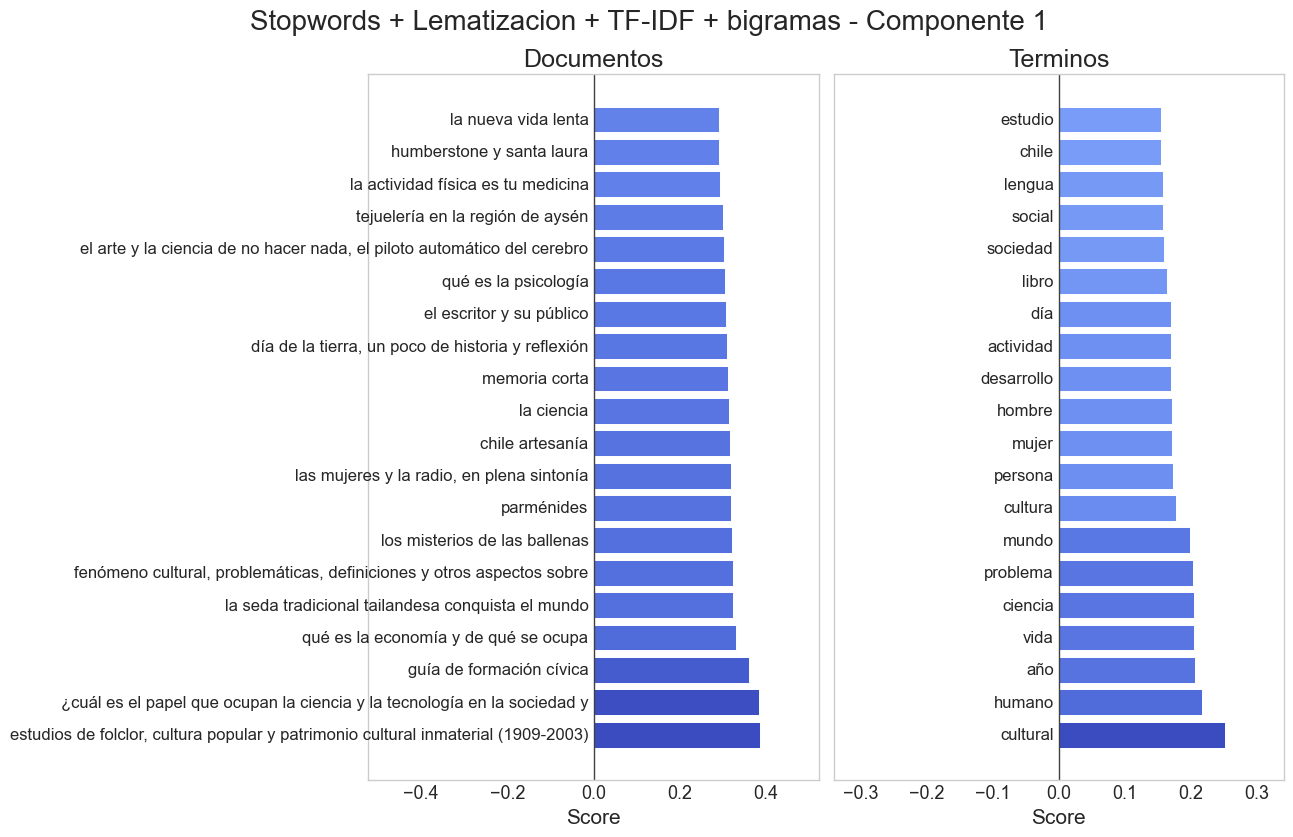

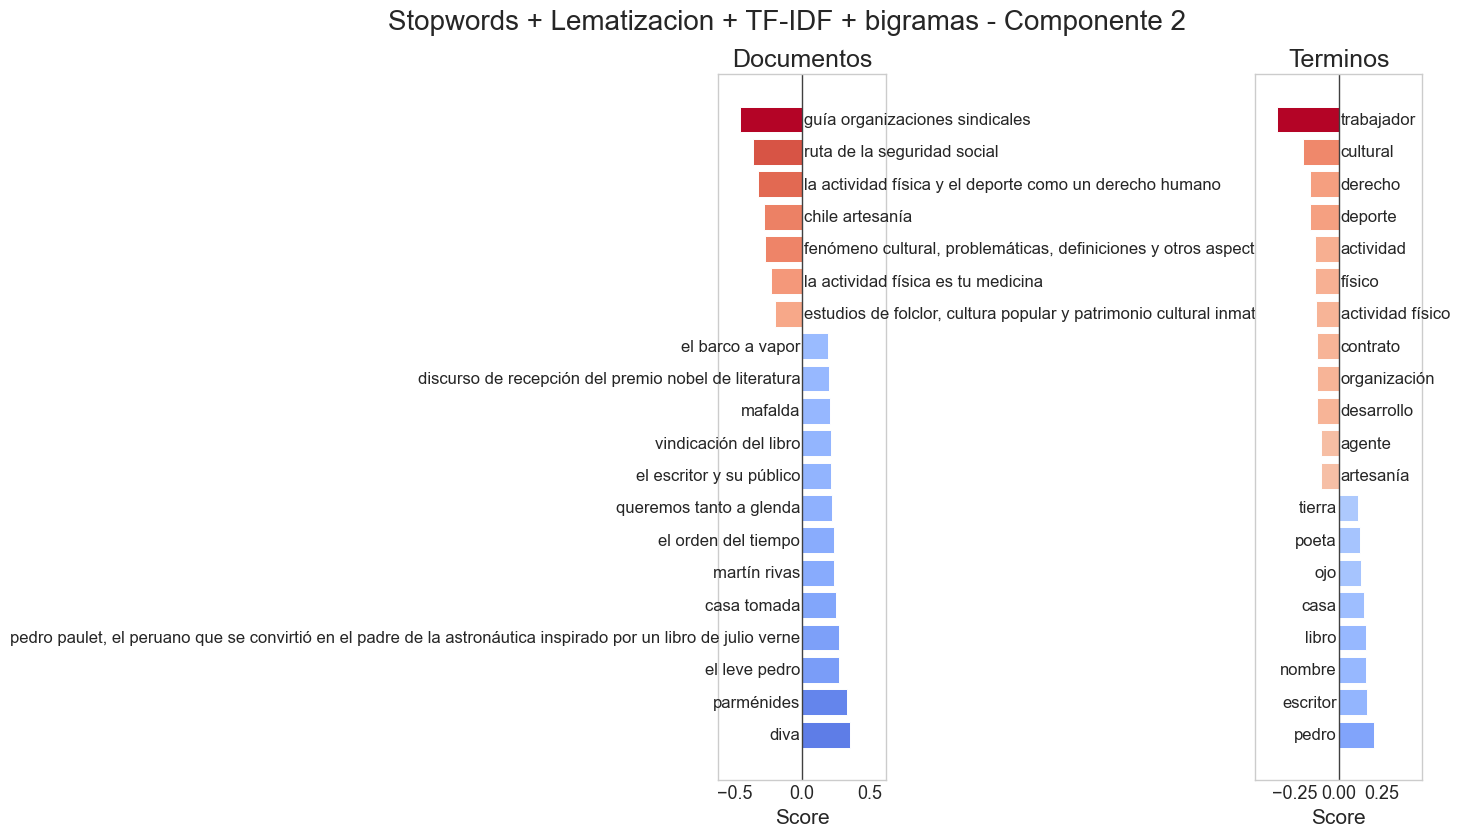

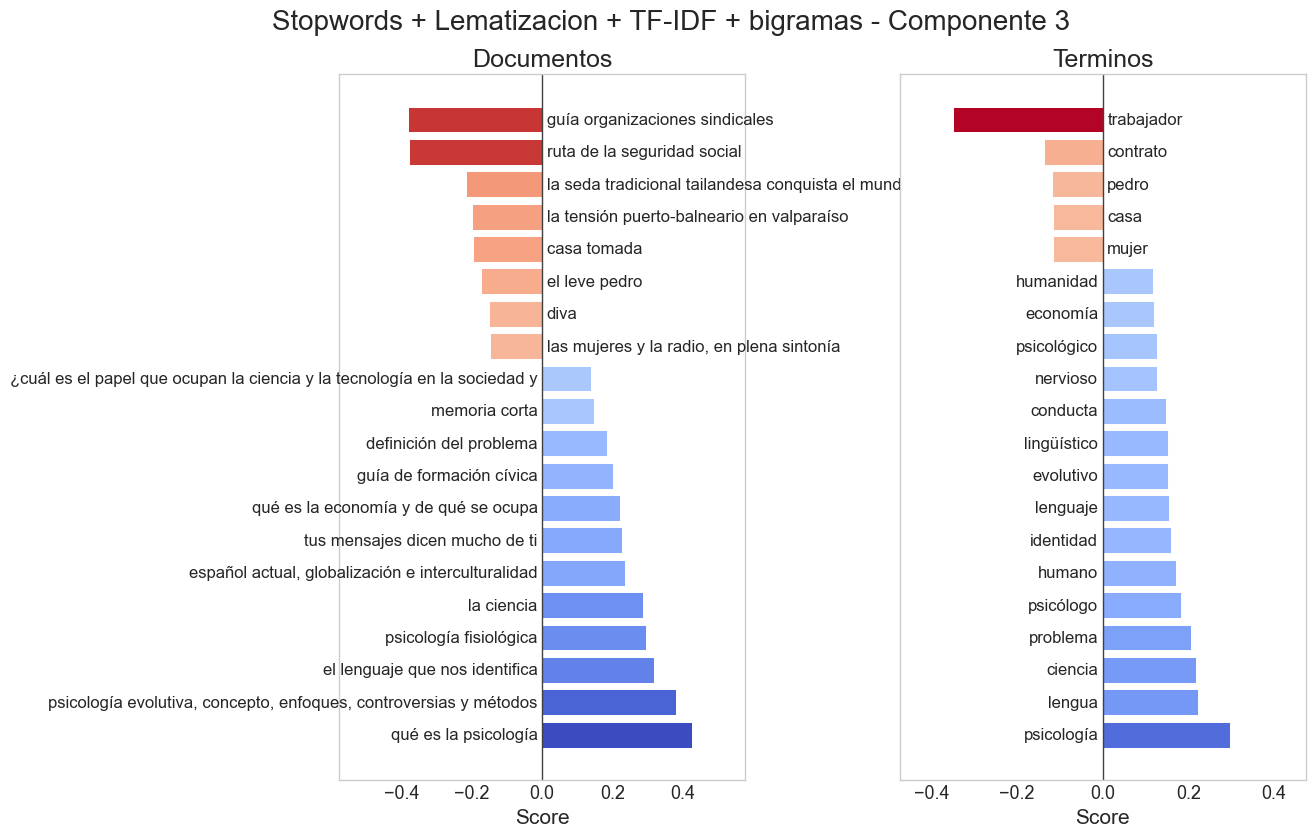

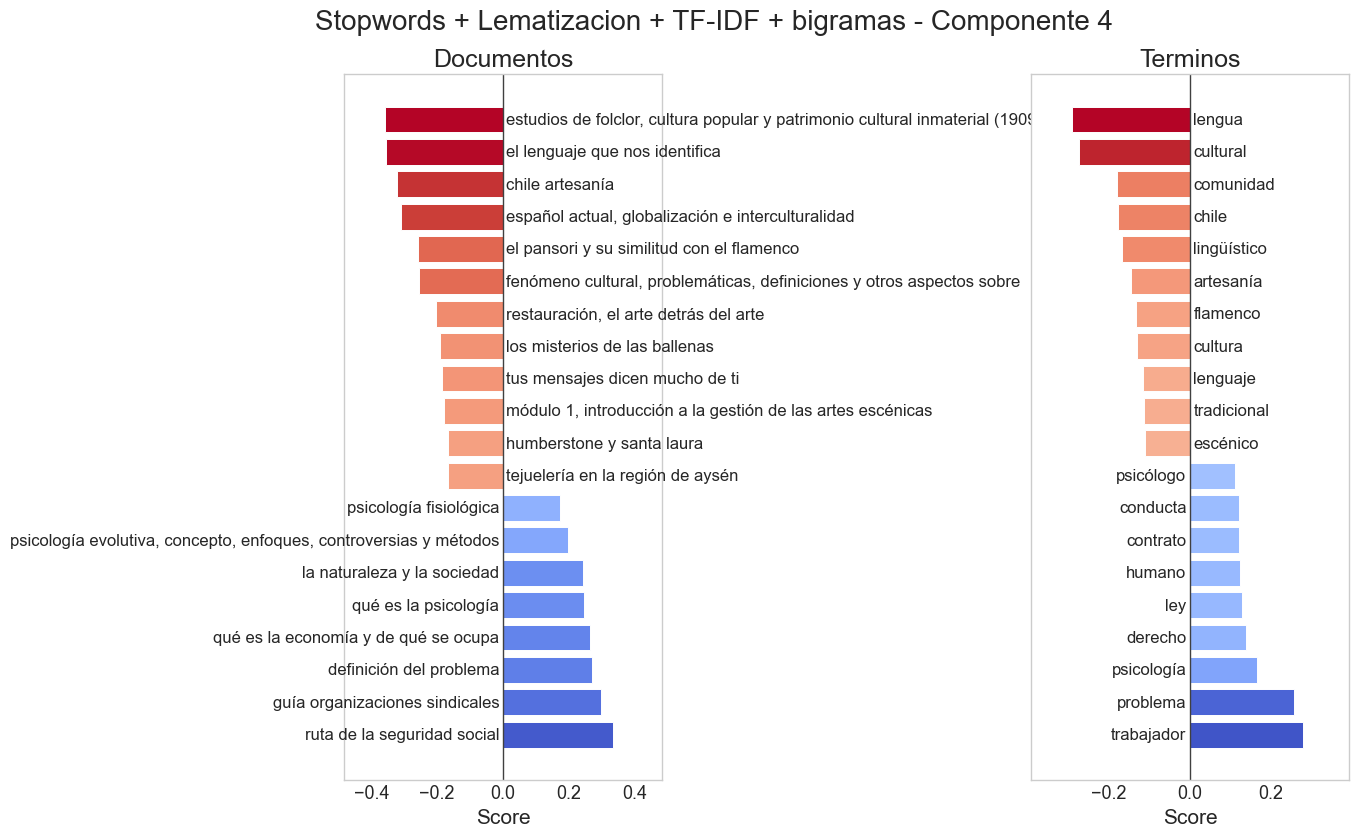

In [49]:
graficar_componentes(
    U_final,
    s_final,
    VT_final,
    vocabulario_final,
    etiquetas,
    componentes=4,
    k=20,
    titulo="Stopwords + Lematizacion + TF-IDF + bigramas",
)